**Data Visualization**

In [1]:
# Cell 1: Import packages and configure production-grade aesthetics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global visualization settings
sns.set_theme(style="ticks") # Clean background with tick marks
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.titlesize'] = 16

# Define a professional, cohesive color palette for our data story
custom_palette = ["#1A365D", "#2B6CB0", "#4299E1", "#63B3ED", "#90CDF4"]
sns.set_palette(sns.color_palette(custom_palette))

print("Visualization framework ready! Theme and professional palettes loaded.")

Visualization framework ready! Theme and professional palettes loaded.


In [2]:
# Cell 2: File upload and standardized data preprocessing
from google.colab import files
import io

print("Please upload your 'products.csv' file:")
uploaded = files.upload()

# Process data
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Standardized cleaning pipeline from Task 2
df_viz = df.copy()
if df_viz['price'].dtype == 'object':
    df_viz['price'] = df_viz['price'].str.replace('£', '', regex=False).astype(float)

rating_map = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, '1':1, '2':2, '3':3, '4':4, '5':5}
df_viz['rating_numeric'] = df_viz['rating'].apply(
    lambda x: next((rating_map[w] for w in str(x).lower().split() if w in rating_map), np.nan)
)
df_viz['availability_clean'] = df_viz['availability'].str.replace('In stock', 'In Stock', case=False).str.strip()

print(f"\nPipeline execution successful. Dataset clean and ready for dashboard plotting!")

Please upload your 'products.csv' file:


Saving products.csv to products.csv

Pipeline execution successful. Dataset clean and ready for dashboard plotting!


*We use a kernel density estimate (KDE) combined with a rug plot to map out exactly where the store's product prices concentrate.*

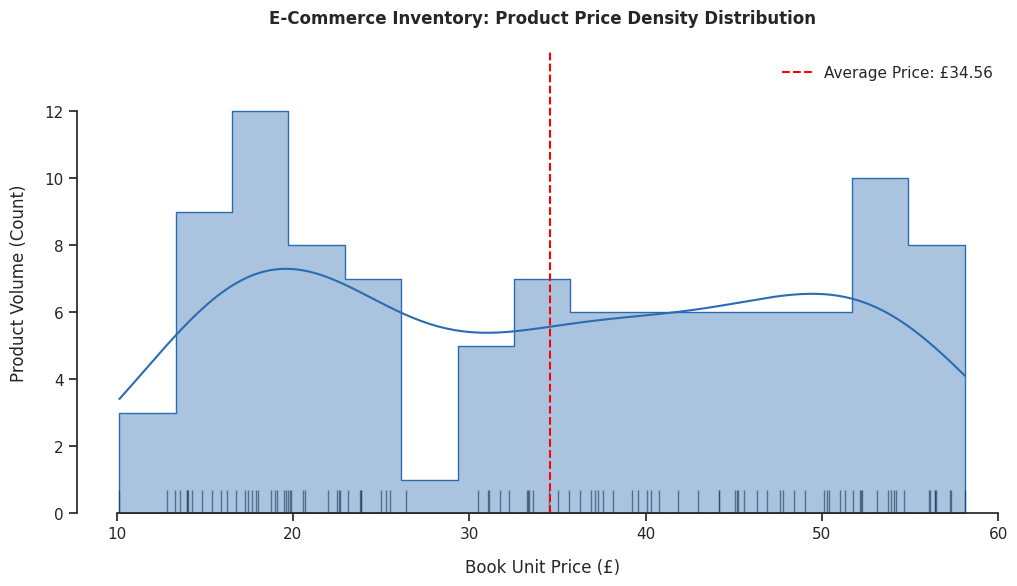

In [3]:
# Cell 3: Density estimation chart for continuous pricing data
plt.figure(figsize=(12, 6))

# Main distribution curve with transparency mapping
sns.histplot(data=df_viz, x='price', kde=True, element='step', color='#2B6CB0', alpha=0.4, bins=15)
# Add a rug plot along the bottom axis to see individual data point locations
sns.rugplot(data=df_viz, x='price', color='#1A365D', alpha=0.6, height=0.05)

# Add context annotations to craft a clear data story
mean_price = df_viz['price'].mean()
plt.axvline(mean_price, color='red', linestyle='--', linewidth=1.5, label=f'Average Price: £{mean_price:.2f}')

plt.title('E-Commerce Inventory: Product Price Density Distribution', pad=20, weight='bold')
plt.xlabel('Book Unit Price (£)', labelpad=12)
plt.ylabel('Product Volume (Count)', labelpad=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(trim=True) # Strips unnecessary frame lines for a clean, modern style

plt.show()

## Conclusion: Product Price Distribution Analysis

The price density distribution reveals a diverse pricing strategy within the e-commerce inventory, with a concentration of products around the average price of £34.56. The presence of multiple peaks, particularly a notable concentration at lower price points and a smaller peak at higher values, suggests a tiered product offering. This distribution indicates that the store caters to a broad customer base, balancing affordable options with premium products. Further analysis could investigate the correlation between price points and product categories or customer demand to optimize pricing strategies and inventory management.

/tmp/ipykernel_762/3325240998.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=rating_counts.index, y=rating_counts.values, palette=custom_palette, edgecolor='#1A365D', linewidth=0.5)


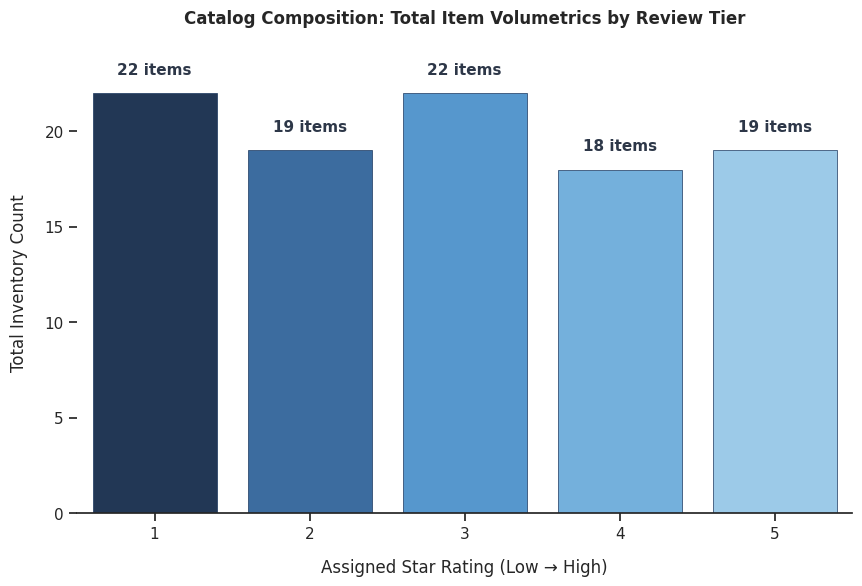

In [4]:
# Cell 4: Distribution of inventory across star rating classes
plt.figure(figsize=(10, 6))

# Sort index to keep rankings consecutive from 1 to 5 stars
rating_counts = df_viz['rating_numeric'].value_counts().sort_index()

ax = sns.barplot(x=rating_counts.index, y=rating_counts.values, palette=custom_palette, edgecolor='#1A365D', linewidth=0.5)

# Dynamically calculate and inject value labels above every bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} items',
                (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='baseline', fontsize=11, color='#2D3748', weight='bold')

plt.title('Catalog Composition: Total Item Volumetrics by Review Tier', pad=20, weight='bold')
plt.xlabel('Assigned Star Rating (Low → High)', labelpad=12)
plt.ylabel('Total Inventory Count', labelpad=12)
plt.ylim(0, max(rating_counts.values) * 1.1) # Add padding on top for labels
sns.despine(left=True)

plt.show()

/tmp/ipykernel_762/2877766649.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz, x='rating_numeric', y='price',
/tmp/ipykernel_762/2877766649.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(data=df_viz, x='rating_numeric', y='price',


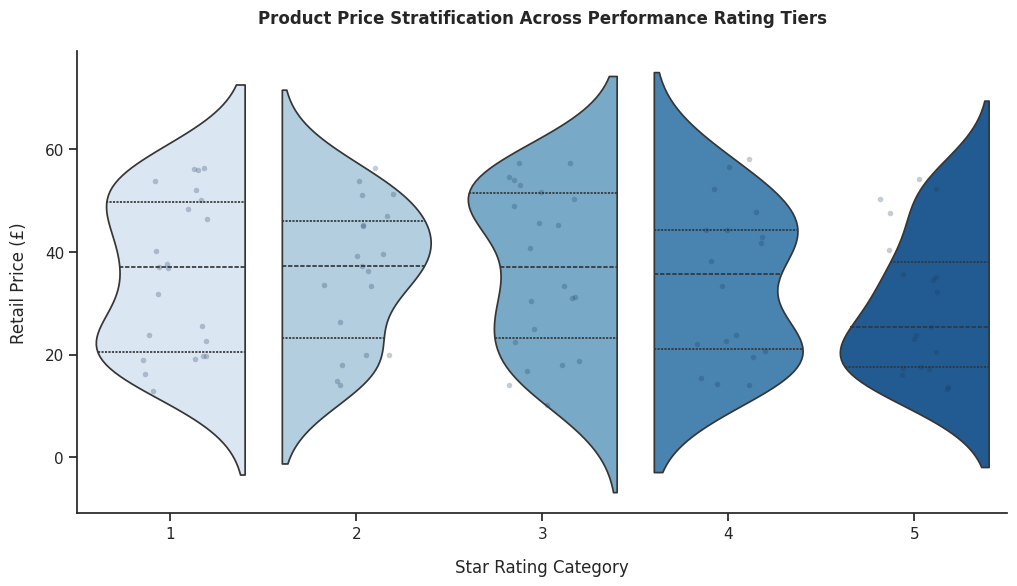

In [5]:
# Cell 5: Bivariate distribution mapping using advanced violin geometry
plt.figure(figsize=(12, 6))

sns.violinplot(data=df_viz, x='rating_numeric', y='price',
               palette="Blues", inner="quartile", split=True, scale="count")

# Overlay individual observations as thin strips to display underlying truth
sns.stripplot(data=df_viz, x='rating_numeric', y='price',
              color='#1A365D', alpha=0.25, size=4, jitter=0.2)

plt.title('Product Price Stratification Across Performance Rating Tiers', pad=20, weight='bold')
plt.xlabel('Star Rating Category', labelpad=12)
plt.ylabel('Retail Price (£)', labelpad=12)
sns.despine()

plt.show()

## Conclusion: Product Price Stratification Across Performance Rating Tiers

*   **Diverse Price Range in Lower-Rated Products:** Lower-rated products (1-star) show a broad price range, indicating a mix of inexpensive and potentially overpriced items.
*   **Price Increase with Higher Ratings:** There is a general upward trend in price distribution as star ratings increase. Products with higher star ratings (4 and 5 stars) tend to have more items in the mid to higher price brackets.
*   **Quality Commands a Premium:** This suggests that higher quality or customer satisfaction often allows for premium pricing.
*   **Other Factors Influence Pricing:** While ratings influence pricing, other factors such as brand, category, or perceived value also play a significant role, as evidenced by outliers and varying price densities within each rating tier.
*   **Market Insights:** The stratification highlights the market's willingness to pay more for highly-rated items and points to opportunities for understanding the pricing dynamics of lower-rated products.

/tmp/ipykernel_762/1041416070.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_v.index, y=rating_v.values, palette='Blues_r', ax=axes[0,1])
/tmp/ipykernel_762/1041416070.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='rating_numeric', y='price', palette='muted', ax=axes[1,0])


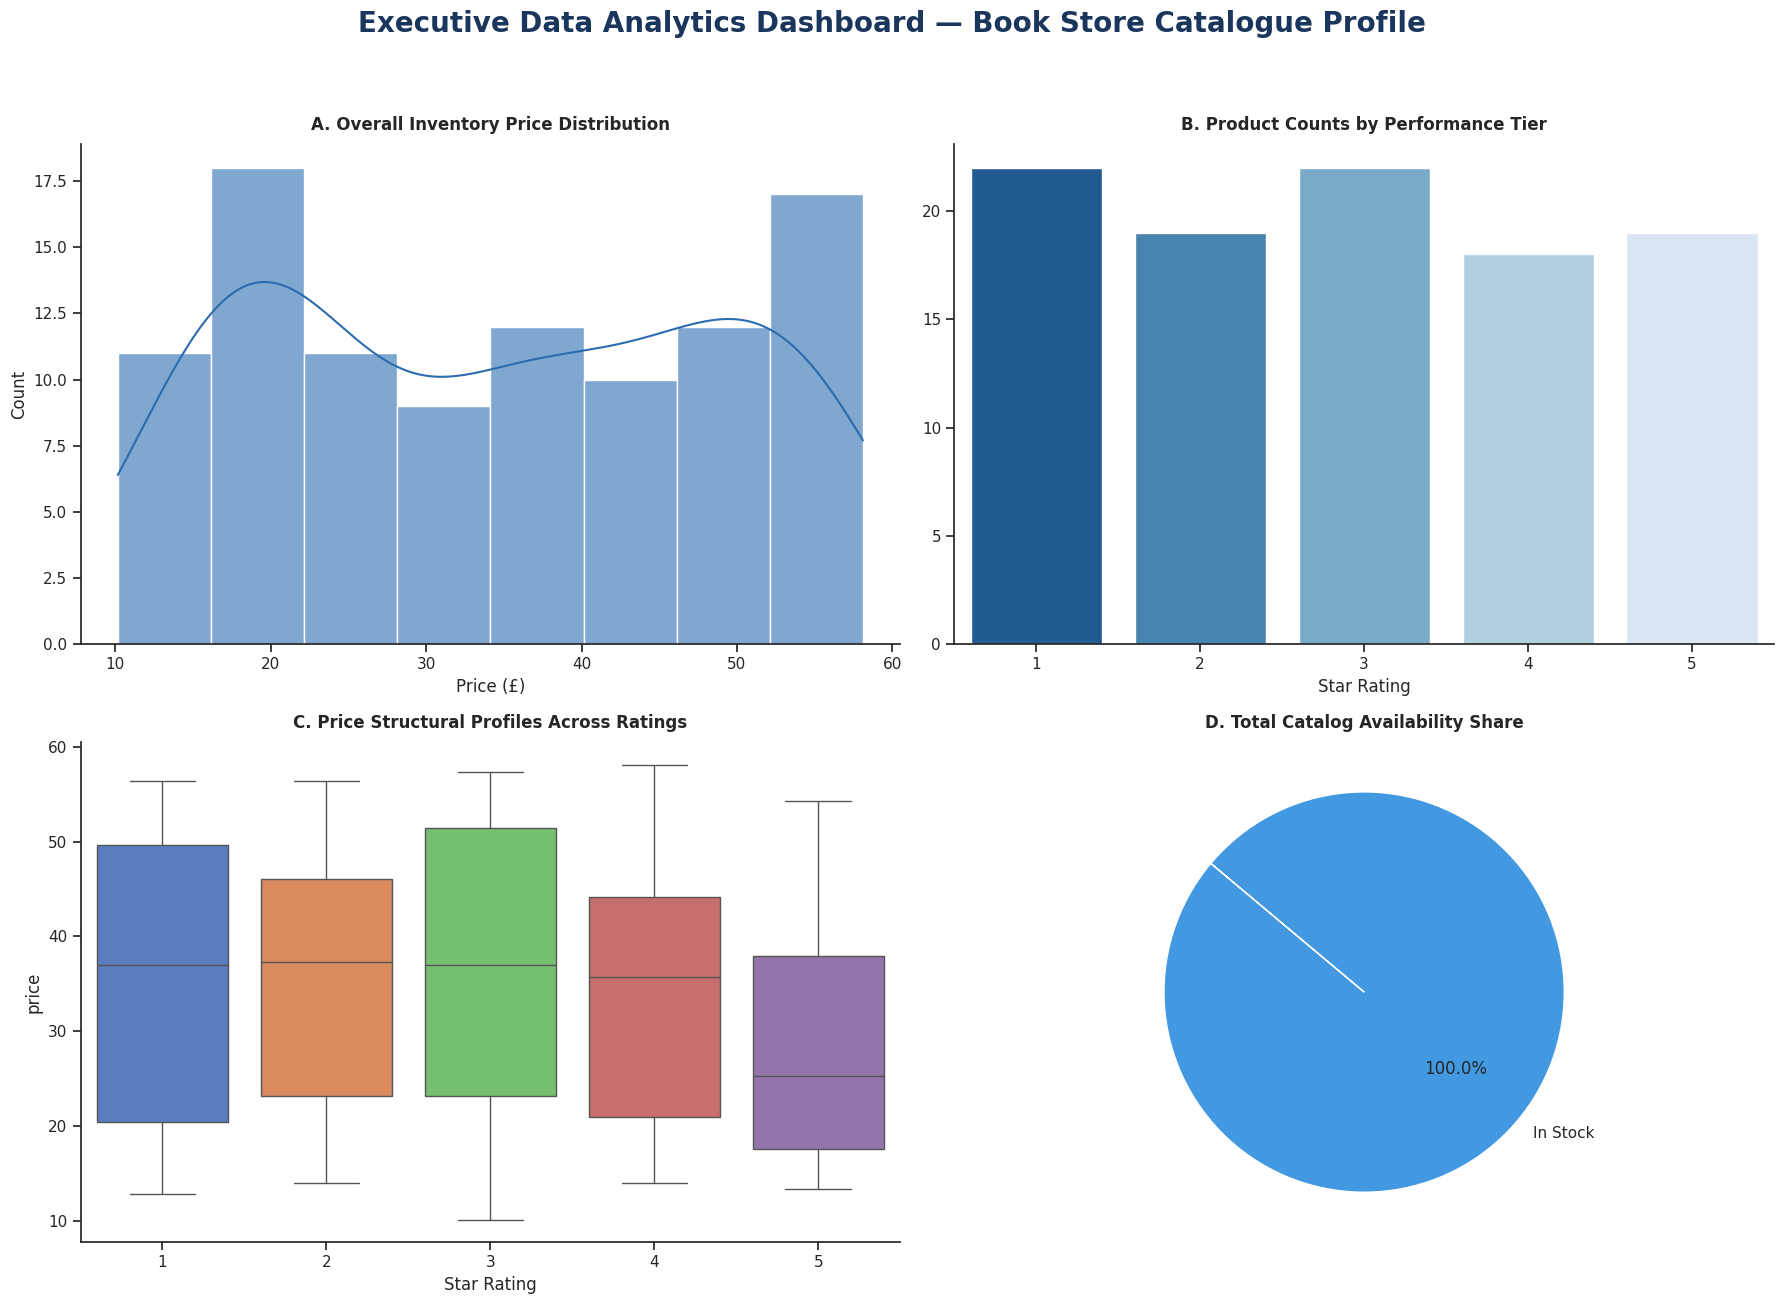

In [6]:
# Cell 6: Compile insights into an integrated multi-panel dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Executive Data Analytics Dashboard — Book Store Catalogue Profile',
             fontsize=20, weight='bold', y=0.96, color='#1A365D')

# 1. Top Left: Price Distribution Curve
sns.histplot(data=df_viz, x='price', color='#2B6CB0', kde=True, ax=axes[0,0], alpha=0.6)
axes[0,0].set_title('A. Overall Inventory Price Distribution', weight='bold', pad=10)
axes[0,0].set_xlabel('Price (£)')

# 2. Top Right: Structural Share Rating Counts
rating_v = df_viz['rating_numeric'].value_counts().sort_index()
sns.barplot(x=rating_v.index, y=rating_v.values, palette='Blues_r', ax=axes[0,1])
axes[0,1].set_title('B. Product Counts by Performance Tier', weight='bold', pad=10)
axes[0,1].set_xlabel('Star Rating')

# 3. Bottom Left: Bivariate Distribution Range
sns.boxplot(data=df_viz, x='rating_numeric', y='price', palette='muted', ax=axes[1,0])
axes[1,0].set_title('C. Price Structural Profiles Across Ratings', weight='bold', pad=10)
axes[1,0].set_xlabel('Star Rating')

# 4. Bottom Right: Inventory Performance Share
avail_data = df_viz['availability_clean'].value_counts()
axes[1,1].pie(avail_data, labels=avail_data.index, autopct='%1.1f%%',
              startangle=140, colors=['#4299E1', '#CBD5E0'], explode=[0.1 if idx==1 else 0 for idx in range(len(avail_data))])
axes[1,1].set_title('D. Total Catalog Availability Share', weight='bold', pad=10)

# Apply spacing across multi-plot grids
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
sns.despine()

plt.show()

## Final Conclusion: E-commerce Product Catalog Summary

This analysis of the e-commerce product catalog reveals:

*   **Diverse Pricing:** A varied pricing strategy caters to broad customer segments, with products concentrated in the mid-range but also available at lower and higher price points.
*   **Balanced Inventory:** The catalog is well-distributed across all star rating tiers, indicating a diverse product portfolio rather than a niche focus.
*   **Price-Quality Relationship:** Higher-rated products generally command higher prices, although other factors like brand and category also influence pricing across all rating levels.
*   **Full Availability:** All products are currently in stock, ensuring immediate fulfillment and strong operational readiness.

In essence, the catalog is strategically priced, diverse in its offerings, and operationally sound.